In [16]:
import pandas as pd 
df=pd.read_csv("heart.csv")
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [17]:
print(df.shape)

(1025, 14)


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [19]:
print(df.isnull.sum())

AttributeError: 'function' object has no attribute 'sum'

In [20]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [21]:
print(df['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


In [22]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

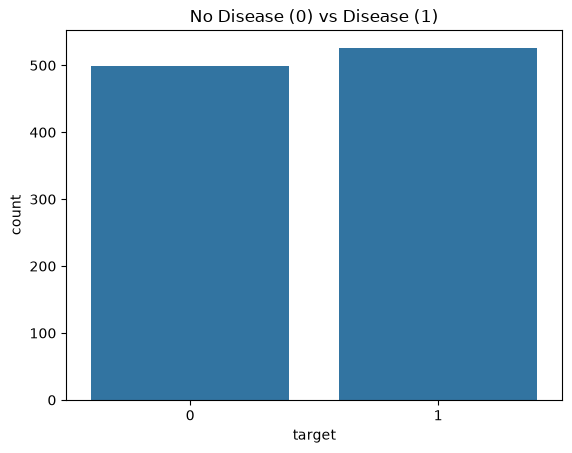

In [24]:
sns.countplot(x='target', data=df)
plt.title("No Disease (0) vs Disease (1)")
plt.show()

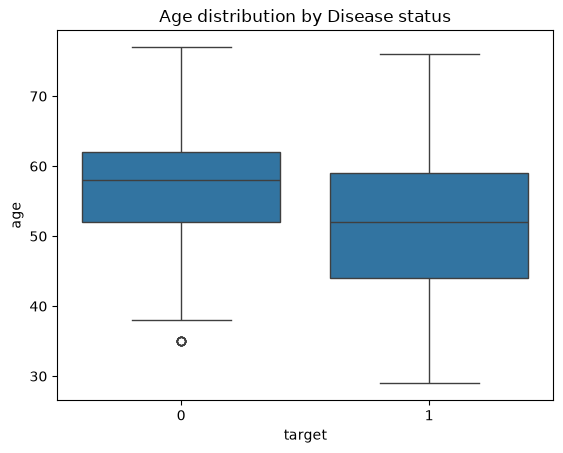

In [25]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age distribution by Disease status")
plt.show()

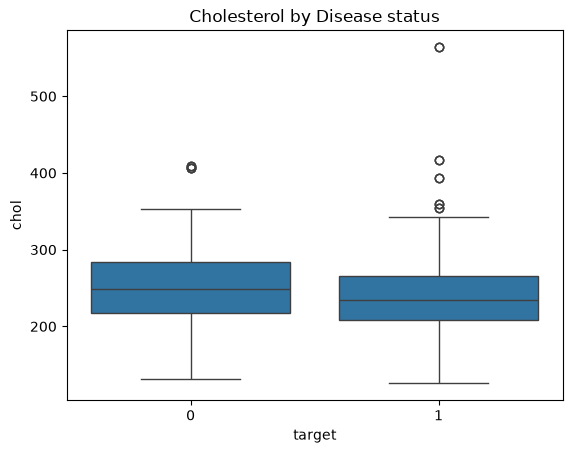

In [26]:
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol by Disease status")
plt.show()

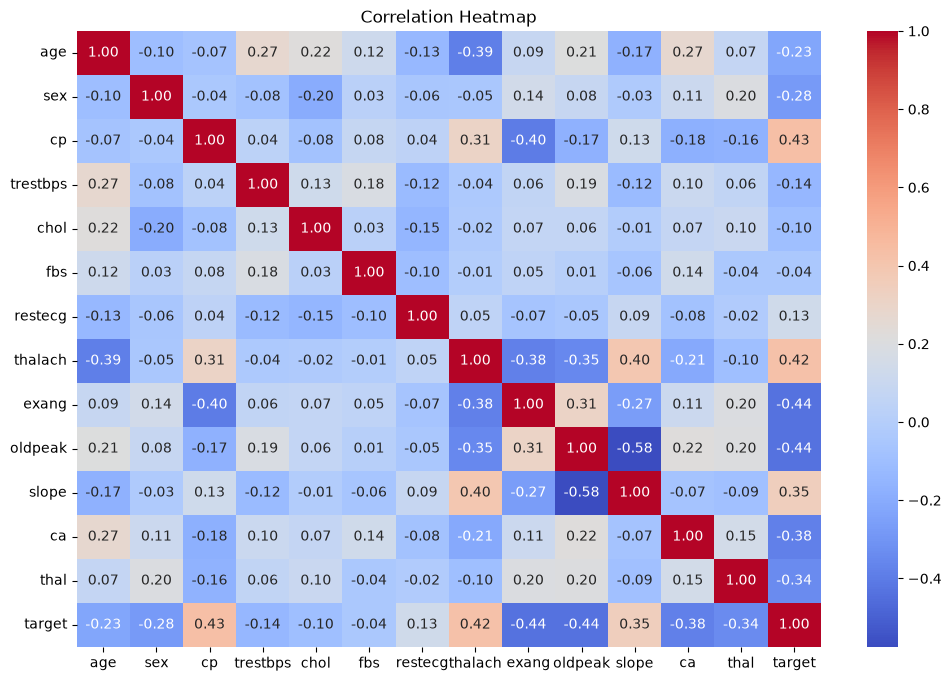

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
X = df.drop("target", axis=1)
y = df["target"]
print(X.shape)
print(y.shape)

(1025, 13)
(1025,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [ ]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/61.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.1 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.1 kB ? eta -:--:--
     -------------------------------------- 61.1/61.1 kB 652.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
    --------------------------------------- 0.2/8.2 MB 5.3 MB/s eta 0:00:02
   - -------------------------------------- 0.3/8.2 MB 3.9 MB/s eta 0:00:03
   -- ------------------------------------- 0.6/8.2 MB 5.4 MB/s eta 0:00:02
   ---- ----------------------------------- 0.9/8.2 MB 5.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.2/8.2 MB 5.5 MB/s eta 0:00:02
   ------- -------------------------------- 1.5/8.2 MB 5.7 MB/s eta 0:00:02
   -------- ------------------------------- 1.7/8.2 MB 5.8 MB/s eta 0:00:02
   --------- -----------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
print(X_train_scaled[:5])


[[ 0.81162633 -1.50996689 -0.90957214  0.31472862  0.89579058  2.34689934
   0.926946   -1.92115501 -0.71813066  0.69652503 -0.59754229  2.20730061
  -0.56245085]
 [ 0.15224695 -1.50996689 -0.90957214  3.76764257  0.77911537  2.34689934
  -0.98284224 -0.72536159  1.39250426  2.47581015 -2.1987994   1.22840039
   1.0906305 ]
 [ 0.26214351  0.66226618  1.04803719 -0.24219298 -0.36819094 -0.42609412
  -0.98284224  0.02754538 -0.71813066 -0.57439291 -0.59754229  0.24950018
   1.0906305 ]
 [ 0.26214351  0.66226618  1.04803719  0.98303455 -2.37111551  2.34689934
   0.926946    1.04618421 -0.71813066 -0.74384864  1.00371482  0.24950018
   1.0906305 ]
 [-0.28733931 -1.50996689  1.04803719  0.2033443  -1.00990464 -0.42609412
  -0.98284224  0.86902963 -0.71813066 -0.8285765  -0.59754229 -0.72940004
  -0.56245085]]


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))

Logistic Regression Accuracy: 0.8097560975609757


In [33]:
# Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_preds))

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Decision Tree Accuracy: 0.9853658536585366
Random Forest Accuracy: 1.0


In [34]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 1025
Duplicate rows: 723


In [35]:
df_clean = df.drop_duplicates()
print(df_clean.shape)

(302, 14)


In [36]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(241, 13)
(61, 13)


In [37]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))

# Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_preds = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_preds))

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Logistic Regression Accuracy: 0.8032786885245902
Decision Tree Accuracy: 0.8032786885245902
Random Forest Accuracy: 0.7540983606557377


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.8589285714285714


In [39]:
best_model = grid_search.best_estimator_

final_preds = best_model.predict(X_test)
print("Final Tuned Random Forest Accuracy on Test Set:", accuracy_score(y_test, final_preds))

Final Tuned Random Forest Accuracy on Test Set: 0.7704918032786885


In [40]:
def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg,
                            thalach, exang, oldpeak, slope, ca, thal):
    
    # Put the inputs into the same format the model expects (a table with 1 row)
    new_patient = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg,
                                   thalach, exang, oldpeak, slope, ca, thal]],
                                 columns=X.columns)
    
    # Make the prediction
    prediction = best_model.predict(new_patient)[0]
    probability = best_model.predict_proba(new_patient)[0]
    
    # Print a readable result
    if prediction == 1:
        print(f"Prediction: Likely HAS heart disease")
    else:
        print(f"Prediction: Likely does NOT have heart disease")
    
    print(f"Confidence: {probability[prediction]*100:.1f}%")
    
    return prediction

In [41]:
predict_heart_disease(
    age=55, sex=1, cp=0, trestbps=140, chol=250, fbs=0, restecg=1,
    thalach=150, exang=0, oldpeak=1.5, slope=2, ca=0, thal=2
)

Prediction: Likely HAS heart disease
Confidence: 67.9%


np.int64(1)

In [42]:
predict_heart_disease(
    age=35, sex=0, cp=0, trestbps=110, chol=180, fbs=0, restecg=0,
    thalach=175, exang=0, oldpeak=0.0, slope=2, ca=0, thal=2
)

Prediction: Likely HAS heart disease
Confidence: 76.6%


np.int64(1)

In [43]:
# Grab a few real patients from the test set and compare predictions to actual answers
sample = X_test.iloc[:5]
actual = y_test.iloc[:5]
predicted = best_model.predict(sample)

comparison = pd.DataFrame({
    "Actual": actual.values,
    "Predicted": predicted
})
print(comparison)

   Actual  Predicted
0       0          0
1       0          1
2       0          0
3       0          1
4       0          1


In [44]:
full_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_model.predict(X_test)
})
full_comparison["Correct"] = full_comparison["Actual"] == full_comparison["Predicted"]
print(full_comparison["Correct"].value_counts())

Correct
True     47
False    14
Name: count, dtype: int64


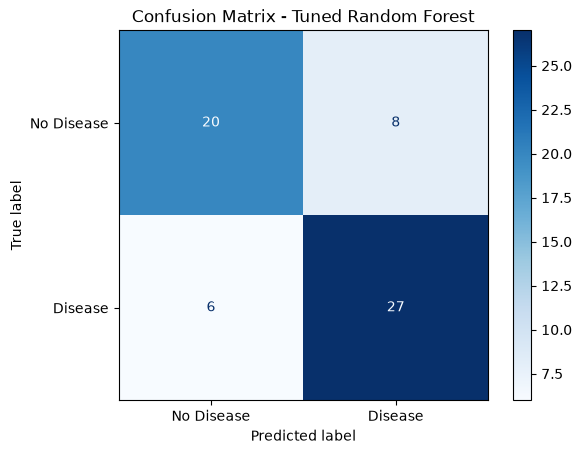

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, best_model.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

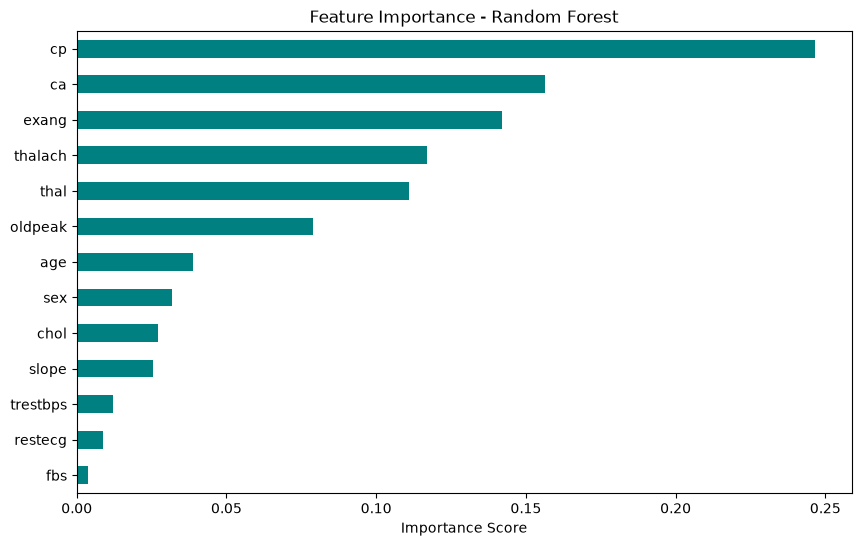

In [46]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [47]:
import joblib

joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")

['feature_names.pkl']